In [80]:
import json
import numpy as np
import os
import pandas as pd
df = pd.read_csv('Daily_more_features.csv',encoding="utf-8")
df.head()

,Date,Close,High,Low,Open,Volume,MA_10,EMA_10,Momentum_10,ATR_10,PP,R1,S1,R2,S2,R3,S3
0,2018/1/1,13657.20020,14112.20020,13154.70020,14112.2002,1.029120e+10,18313.25477,18311.59754,229.393304,1030.3867,13641.36687,14128.03353,13170.53353,14598.86687,12683.86687,15085.53353,12213.03353
1,2018/1/2,14982.09961,15444.59961,13163.59961,13625.0000,1.684660e+10,18313.25477,18311.59754,229.393304,1030.3867,14530.09961,15896.59961,13615.59961,16811.09961,12249.09961,18177.59961,11334.59961
2,2018/1/3,15201.00000,15572.79981,14844.50000,14978.2002,1.687190e+10,18313.25477,18311.59754,229.393304,1030.3867,15206.09994,15567.69987,14839.40006,15934.39975,14477.80013,16295.99968,14111.10025
3,2018/1/4,15599.20020,15739.70020,14522.20020,15270.7002,2.178320e+10,18313.25477,18311.59754,229.393304,1030.3867,15287.03353,16051.86687,14834.36687,16504.53353,14069.53353,17269.36687,13616.86687
4,2018/1/5,17429.50000,17705.19922,15202.79981,15477.2002,2.384090e+10,18313.25477,18311.59754,229.393304,1030.3867,16779.16634,18355.53288,15853.13347,19281.56575,14276.76693,20857.93229,13350.73406


In [81]:
hist = df.set_index('Date')
hist.index = pd.to_datetime(hist.index)
target_col = 'Close'
hist.head(5)

,Close,High,Low,Open,Volume,MA_10,EMA_10,Momentum_10,ATR_10,PP,R1,S1,R2,S2,R3,S3
Date,,,,,,,,,,,,,,,,
2018-01-01,13657.20020,14112.20020,13154.70020,14112.2002,1.029120e+10,18313.25477,18311.59754,229.393304,1030.3867,13641.36687,14128.03353,13170.53353,14598.86687,12683.86687,15085.53353,12213.03353
2018-01-02,14982.09961,15444.59961,13163.59961,13625.0000,1.684660e+10,18313.25477,18311.59754,229.393304,1030.3867,14530.09961,15896.59961,13615.59961,16811.09961,12249.09961,18177.59961,11334.59961
2018-01-03,15201.00000,15572.79981,14844.50000,14978.2002,1.687190e+10,18313.25477,18311.59754,229.393304,1030.3867,15206.09994,15567.69987,14839.40006,15934.39975,14477.80013,16295.99968,14111.10025
2018-01-04,15599.20020,15739.70020,14522.20020,15270.7002,2.178320e+10,18313.25477,18311.59754,229.393304,1030.3867,15287.03353,16051.86687,14834.36687,16504.53353,14069.53353,17269.36687,13616.86687
2018-01-05,17429.50000,17705.19922,15202.79981,15477.2002,2.384090e+10,18313.25477,18311.59754,229.393304,1030.3867,16779.16634,18355.53288,15853.13347,19281.56575,14276.76693,20857.93229,13350.73406


In [101]:
def train_test_split(df, test_size=0.15):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [102]:
train, test = train_test_split(hist, test_size=0.15)

In [103]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);

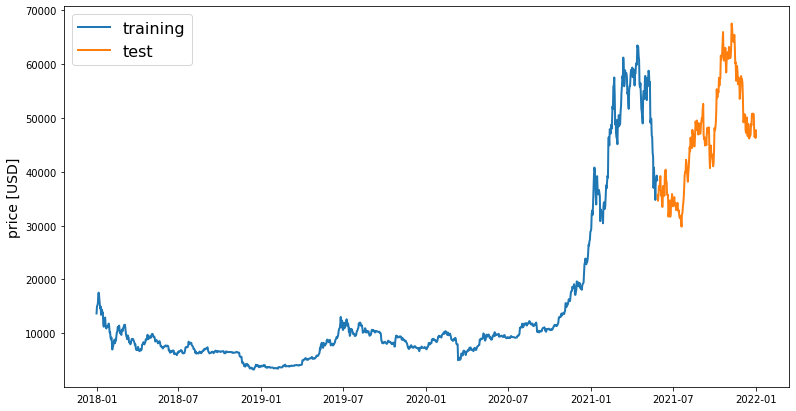

In [104]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error


line_plot(train[target_col], test[target_col], 'training', 'test', title='')

In [105]:
#Data pre-processing - Normalisation
def normalise_zero_base(df):
    return df / df.iloc[0] - 1

def normalise_min_max(df):
    return (df - df.min()) / (data.max() - df.min())

In [106]:
def extract_window_data(df, window_len=5, zero_base=True):
    window_data = []
    for idx in range(len(df) - window_len):
        tmp = df[idx: (idx + window_len)].copy()
        if zero_base:
            tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [116]:
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.15):
    train_data, test_data = train_test_split(df, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

In [127]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [128]:
np.random.seed(42)
window_len = 5
test_size = 0.15
zero_base = True
lstm_neurons = 100
epochs = 29
batch_size = 32
loss = 'mse'
dropout = 0.2
optimizer = 'adam'

In [129]:
train, test, X_train, X_test, y_train, y_test = prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [130]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

Train on 1238 samples, validate on 214 samples
Epoch 1/29
1238/1238 [==============================] - 3s 3ms/step - loss: 0.0142 - val_loss: 0.0035
Epoch 2/29
1238/1238 [==============================] - 1s 673us/step - loss: 0.0085 - val_loss: 0.0022
Epoch 3/29
1238/1238 [==============================] - 1s 670us/step - loss: 0.0062 - val_loss: 0.0023
Epoch 4/29
1238/1238 [==============================] - 1s 668us/step - loss: 0.0054 - val_loss: 0.0026
Epoch 5/29
1238/1238 [==============================] - 1s 673us/step - loss: 0.0048 - val_loss: 0.0024
Epoch 6/29
1238/1238 [==============================] - 1s 673us/step - loss: 0.0038 - val_loss: 0.0024
Epoch 7/29
1238/1238 [==============================] - 1s 656us/step - loss: 0.0041 - val_loss: 0.0017
Epoch 8/29
1238/1238 [==============================] - 1s 665us/step - loss: 0.0039 - val_loss: 0.0017
Epoch 9/29
1238/1238 [==============================] - 1s 687us/step - loss: 0.0035 - val_loss: 0.0017
Epoch 10/29
1238/12

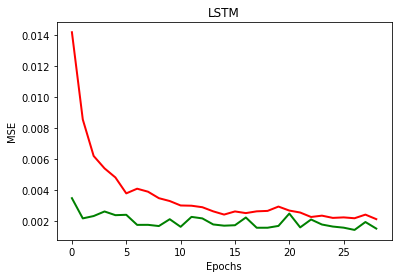

In [131]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Validation loss')
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [132]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
MAE=mean_absolute_error(preds, y_test)
MAE

0.029854442344918297

In [133]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(preds, y_test)
MSE
import math
RMSE=math.sqrt(MSE)
RMSE

0.03869600739547837

In [134]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, preds)
R2

0.7514772013766001

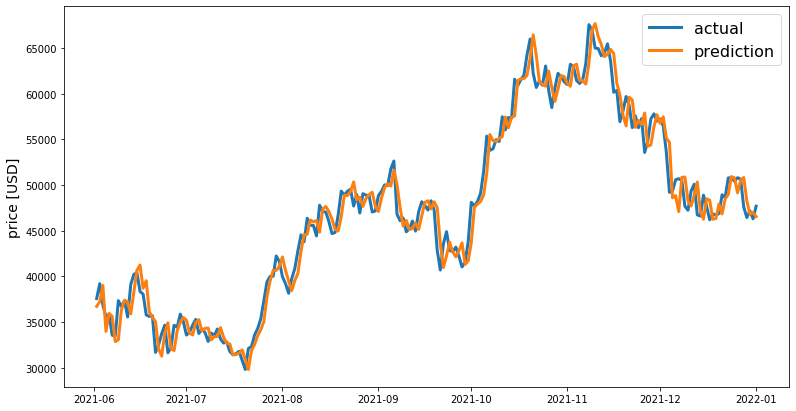

In [135]:
preds = test[target_col].values[:-window_len] * (preds + 1)
preds = pd.Series(index=targets.index, data=preds)
line_plot(targets, preds, 'actual', 'prediction', lw=3)